# Visualizations for Presentation

Dieses Notebook ist eine kompakte Sammlung von Visualisierungen für die Praesentation. 

## Ziel

Import der notwendigen Libraries und Pfade zu den CSVs:

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13

DATA_DIR = Path("CSV")
MARATHON_PATH = DATA_DIR / "vienna_city_marathon_all_years_participants.csv"
WEATHER_PATH = DATA_DIR / "vie_weather.csv"
AIR_QUALITY_PATH = DATA_DIR / "vienna_marathon_component_trends.csv"

In [18]:
marathon_df = pd.read_csv(MARATHON_PATH)
marathon_df["run_duration"] = pd.to_timedelta(marathon_df["run_time"], errors="coerce")
marathon_df["run_hours"] = marathon_df["run_duration"].dt.total_seconds() / 3600
marathon_df = marathon_df.dropna(subset=["year", "run_hours"]).copy()

weather_df = pd.read_csv(
    WEATHER_PATH,
    sep=";",
    decimal=",",
    skiprows=1,
)
weather_df["REF_YEAR"] = pd.to_numeric(weather_df["REF_YEAR"], errors="coerce")
weather_df["T"] = pd.to_numeric(weather_df["T"], errors="coerce")
weather_df["PRECP_SUM"] = pd.to_numeric(weather_df["PRECP_SUM"], errors="coerce")

air_quality_df = pd.read_csv(AIR_QUALITY_PATH)
air_quality_df["Year"] = pd.to_numeric(air_quality_df["Year"], errors="coerce")

print({
    "marathon_rows": len(marathon_df),
    "weather_rows": len(weather_df),
    "air_quality_rows": len(air_quality_df),
})

{'marathon_rows': 53004, 'weather_rows': 1847, 'air_quality_rows': 26}


## 1. Teilnehmer pro Jahr

Die erste Visualisierung zeigt die Entwicklung der Teilnehmerzahlen ueber die erweiterten Jahrgaenge hinweg. Das eignet sich gut als Einstieg, weil die Zeitreihe sofort den Umfang des Datensatzes sichtbar macht.

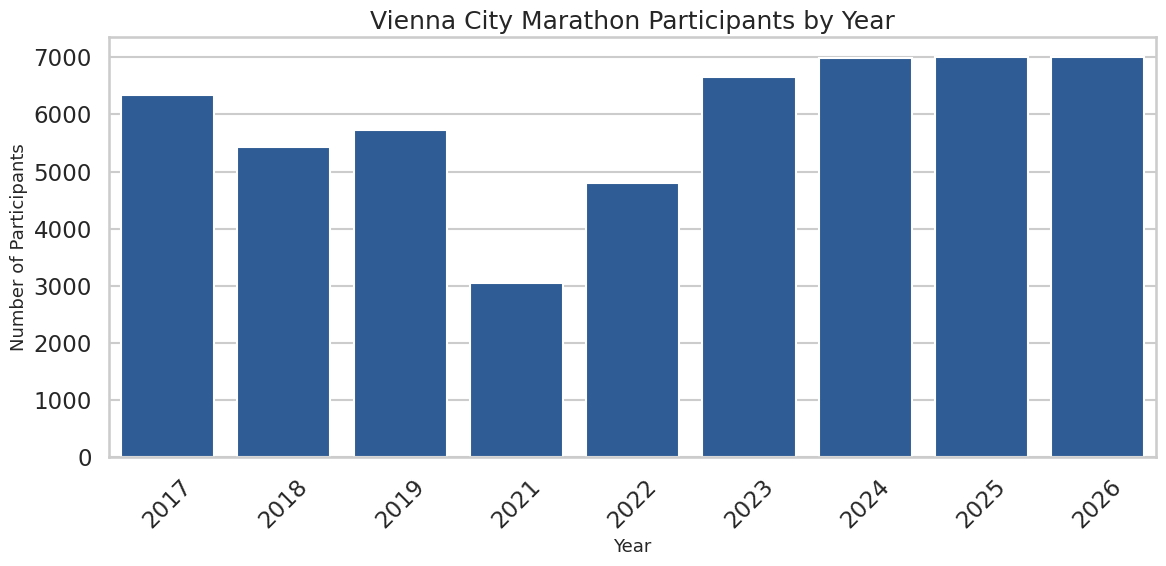

,year,participants
0,2017,6340
1,2018,5436
2,2019,5733
3,2021,3047
4,2022,4803
5,2023,6650
6,2024,6995
7,2025,7000
8,2026,7000


In [3]:
participants_per_year = (
    marathon_df.groupby("year")["participant_id"]
    .nunique()
    .reset_index(name="participants")
    .sort_values("year")
)

ax = sns.barplot(
    data=participants_per_year,
    x="year",
    y="participants",
    color="#1f5aa6",
)
ax.set_title("Vienna City Marathon Participants by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Participants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

participants_per_year

## Schnellste 50 Laufzeiten pro Jahr

Diese Darstellung eignet sich gut fuer einen qualitativen Vergleich zwischen den Jahren. Pro Jahr wird die Elite-Spitze vom schnellsten bis zum 50. schnellsten Ergebnis gezeigt.

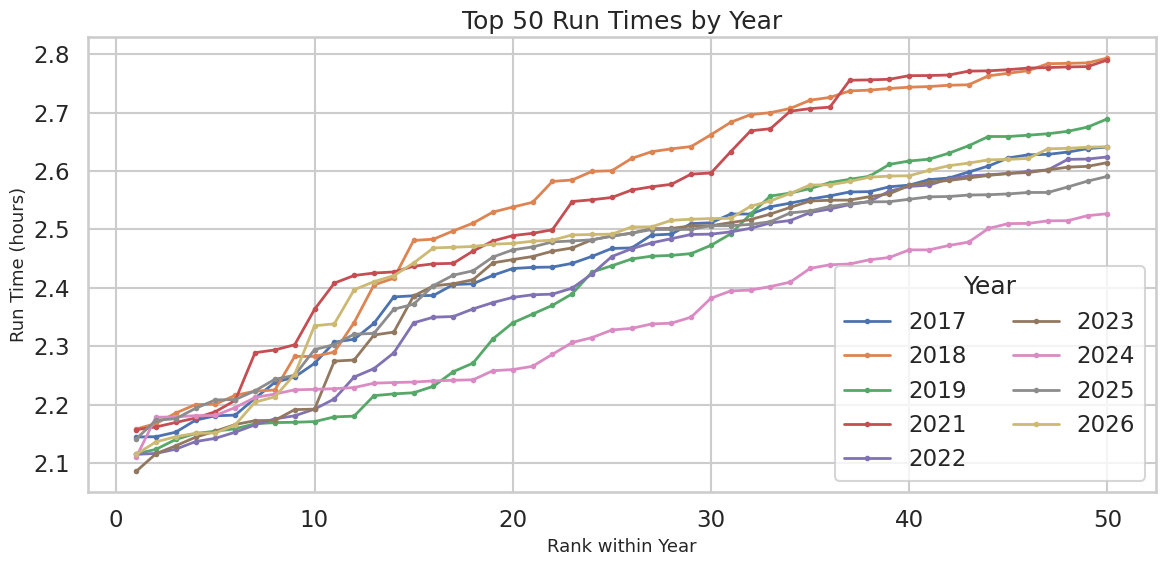

,year,avg_top_50_hours,avg_top_1000_hours
0,2017,2.442572,3.116924
1,2018,2.552578,3.300330
2,2019,2.409578,3.174321
3,2021,2.543383,3.489792
4,2022,2.409267,3.127809
5,2023,2.429778,3.063252
6,2024,2.337167,2.981446
7,2025,2.436933,2.954827
8,2026,2.463056,3.022229


In [19]:
runtime_rank_df = marathon_df[["year", "run_hours"]].copy()
runtime_rank_df = runtime_rank_df.sort_values(["year", "run_hours"]).reset_index(drop=True)
runtime_rank_df["rank_in_year"] = runtime_rank_df.groupby("year").cumcount() + 1

def average_top_n_by_year(rank_df, top_n):
    return (
        rank_df[rank_df["rank_in_year"] <= top_n]
        .groupby("year", as_index=False)["run_hours"]
        .mean()
        .rename(columns={"run_hours": f"avg_top_{top_n}_hours"})
    )

top_50_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 50].copy()
top_50_average_df = average_top_n_by_year(runtime_rank_df, 50)
top_1000_average_df = average_top_n_by_year(runtime_rank_df, 1000)
top_n_average_df = (
    top_50_average_df.merge(top_1000_average_df, on="year", how="inner")
    .sort_values("year")
)

plt.figure(figsize=(12, 6))
for year, year_df in top_50_runtime_df.groupby("year"):
    plt.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        marker="o",
        linewidth=2,
        markersize=3,
        label=str(int(year)),
    )

plt.title("Top 50 Run Times by Year")
plt.xlabel("Rank within Year")
plt.ylabel("Run Time (hours)")
plt.legend(title="Year", ncol=2)
plt.tight_layout()
plt.show()

top_n_average_df

## 3. Temperatur im Marathon-Monat

Die Wetterdatei enthaelt Monatswerte. Deshalb verwenden wir hier den April als beste Naeherung fuer die Bedingungen rund um den Vienna City Marathon und zeigen die Durchschnittstemperatur pro Jahr als Balkendiagramm.

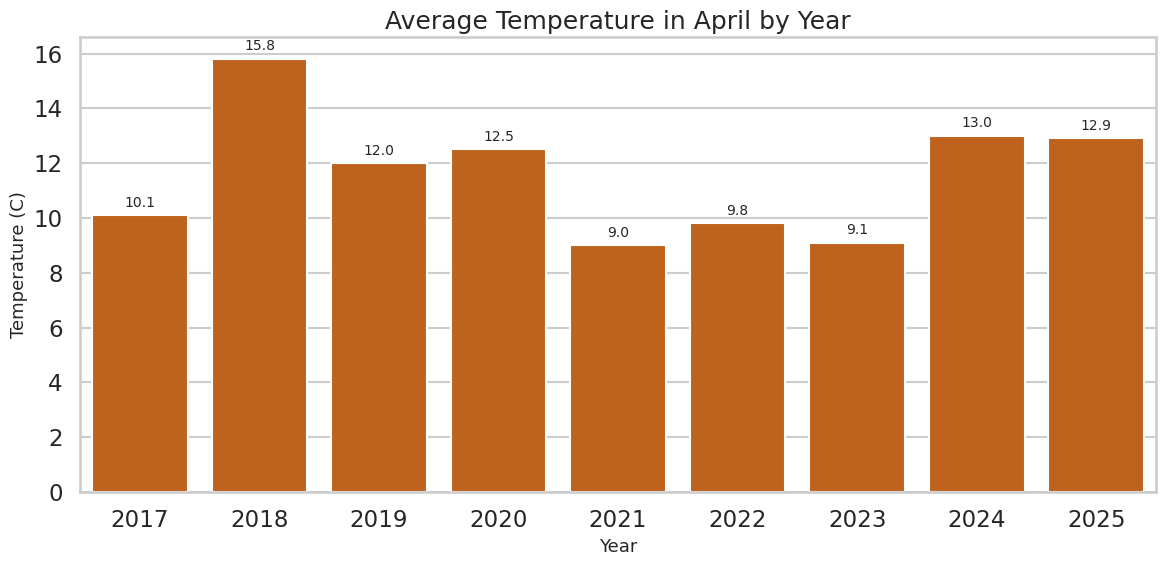

,year,temperature_c
1739,2017,10.1
1751,2018,15.8
1763,2019,12.0
1775,2020,12.5
1787,2021,9.0
1799,2022,9.8
1811,2023,9.1
1823,2024,13.0
1835,2025,12.9


In [20]:
weather_recent_df = weather_df[weather_df["REF_YEAR"] >= 2017].copy()
weather_recent_df["REF_DATE"] = weather_recent_df["REF_DATE"].astype(str)
weather_april_df = weather_recent_df[weather_recent_df["REF_DATE"].str.endswith("04")].copy()

marathon_month_temperature_df = (
    weather_april_df[["REF_YEAR", "T"]]
    .dropna()
    .rename(columns={"REF_YEAR": "year", "T": "temperature_c"})
    .sort_values("year")
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=marathon_month_temperature_df,
    x="year",
    y="temperature_c",
    color="#d95f02",
)

ax.set_title("Average Temperature in April by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (C)")

for patch, value in zip(ax.patches, marathon_month_temperature_df["temperature_c"]):
    ax.annotate(
        f"{value:.1f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

marathon_month_temperature_df

## 4. Temperatur: Top 50 vs. Top 1000

Hier wird bewusst die Elite mit einer deutlich breiteren Leistungsgruppe verglichen. Wenn Temperatur fuer normale schnelle Laeufer wichtiger ist als fuer die absolute Spitze, sollte sich das im rechten Plot klarer zeigen als im linken.

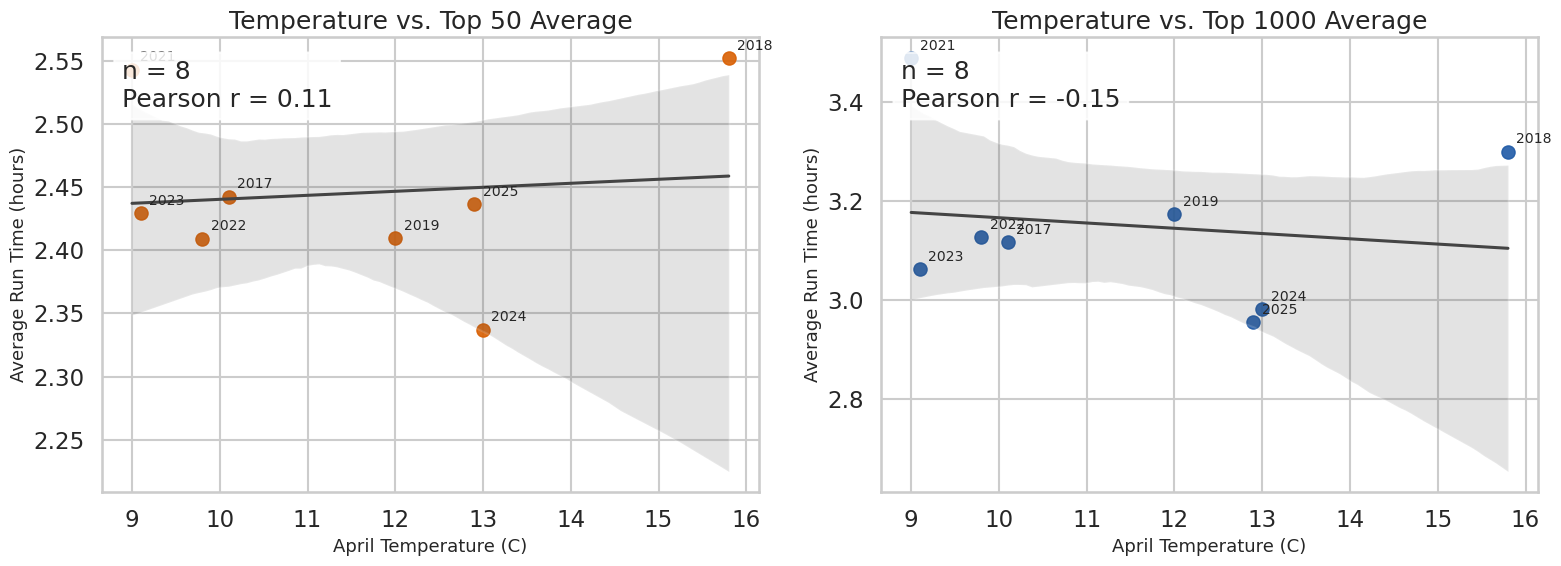

(   year  temperature_c  avg_top_50_hours  avg_top_1000_hours
 0  2017           10.1          2.442572            3.116924
 1  2018           15.8          2.552578            3.300330
 2  2019           12.0          2.409578            3.174321
 3  2021            9.0          2.543383            3.489792
 4  2022            9.8          2.409267            3.127809
 5  2023            9.1          2.429778            3.063252
 6  2024           13.0          2.337167            2.981446
 7  2025           12.9          2.436933            2.954827,
       group  observations  pearson_correlation
 0    Top 50             8             0.106187
 1  Top 1000             8            -0.145345)

In [21]:
performance_vs_temperature_df = (
    marathon_month_temperature_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

temperature_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(performance_vs_temperature_df),
            "pearson_correlation": performance_vs_temperature_df["temperature_c"].corr(
                performance_vs_temperature_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(performance_vs_temperature_df),
            "pearson_correlation": performance_vs_temperature_df["temperature_c"].corr(
                performance_vs_temperature_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#d95f02"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#1f5aa6"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_temperature_df,
        x="temperature_c",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_temperature_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["temperature_c"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = temperature_correlation_table.loc[
        temperature_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Temperature vs. {label} Average")
    ax.set_xlabel("April Temperature (C)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_temperature_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_temperature_df, temperature_correlation_table

## 5. Luftqualitaets-Trends

Die Luftqualitaetsdaten ergaenzen die Praesentation um einen zweiten staedtischen Kontext. Fuer die Folien sind vor allem PM10, PM2.5 und NO2 gute Kandidaten, weil sie gut bekannt und leicht erklaerbar sind.

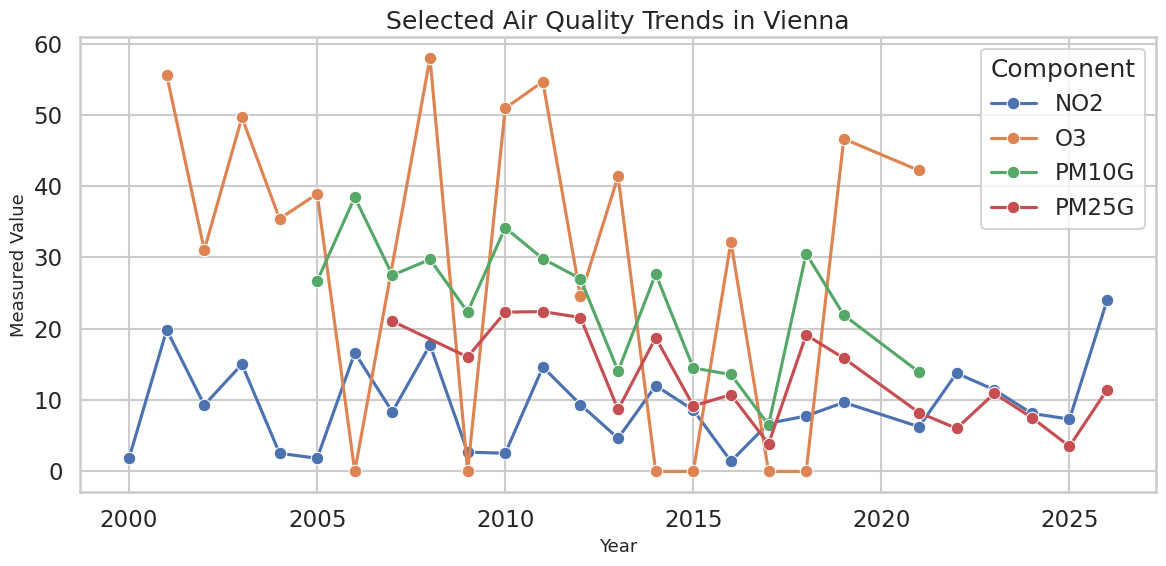

In [10]:
selected_components = ["NO2", "O3", "PM10G", "PM25G"]
available_components = [col for col in selected_components if col in air_quality_df.columns]
air_quality_long_df = air_quality_df[["Year"] + available_components].melt(
    id_vars="Year",
    var_name="component",
    value_name="value",
)
air_quality_long_df = air_quality_long_df.dropna(subset=["Year", "value"])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=air_quality_long_df,
    x="Year",
    y="value",
    hue="component",
    marker="o",
)
plt.title("Selected Air Quality Trends in Vienna")
plt.xlabel("Year")
plt.ylabel("Measured Value")
plt.legend(title="Component")
plt.tight_layout()
plt.show()

## 6. PM2.5: Top 50 vs. Top 1000

PM2.5 ist fuer Ausdauersport plausibel, weil feinere Partikel die Atmung und damit die Belastung ueber die gesamte Renndauer beeinflussen koennen. Fuer die Praesentation ist hier besonders interessant, ob der Zusammenhang fuer die breitere schnelle Gruppe staerker ausfaellt als fuer die Elite.

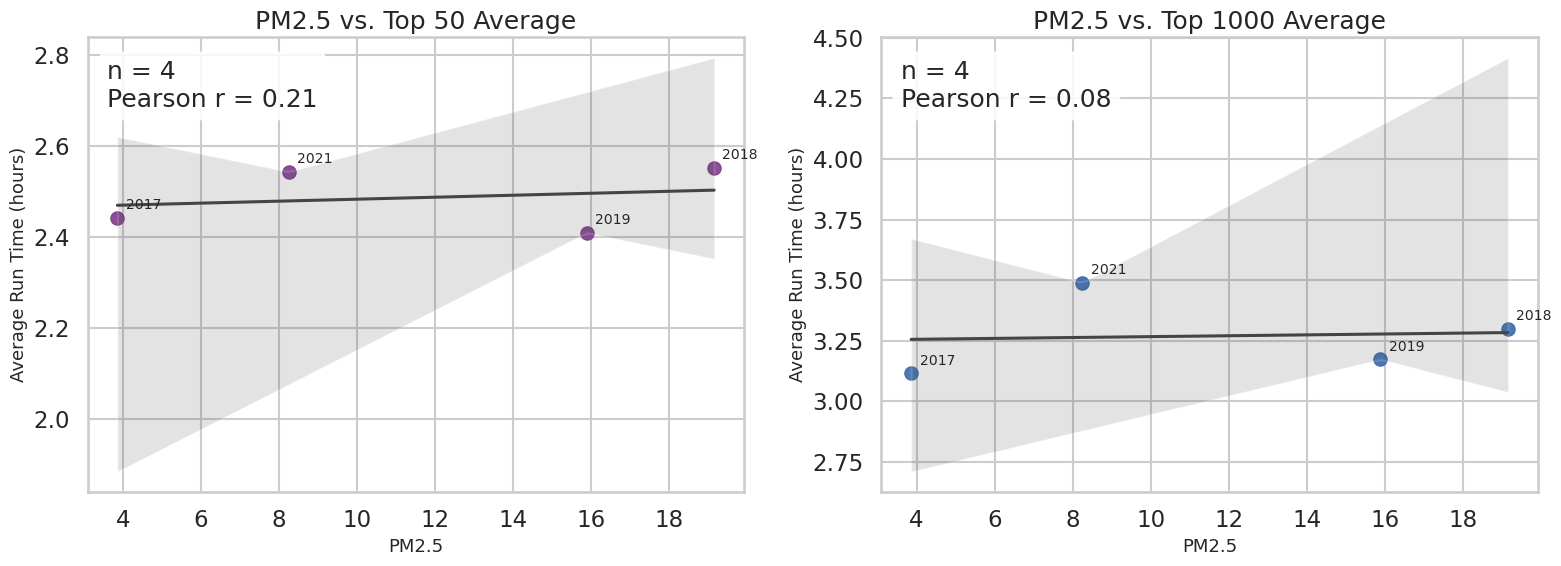

(   year       pm25         o3  avg_top_50_hours  avg_top_1000_hours
 0  2017   3.860000   0.000000          2.442572            3.116924
 1  2018  19.144000   0.000000          2.552578            3.300330
 2  2019  15.875500  46.645400          2.409578            3.174321
 3  2021   8.245162  42.207667          2.543383            3.489792,
       group  observations  pearson_correlation
 0    Top 50             4             0.211849
 1  Top 1000             4             0.077174)

In [22]:
air_performance_df = air_quality_df[["Year", "PM25G", "O3"]].copy()
air_performance_df = air_performance_df.rename(
    columns={"Year": "year", "PM25G": "pm25", "O3": "o3"}
)
air_performance_df = air_performance_df.dropna(subset=["year", "pm25", "o3"])

air_performance_comparison_df = (
    air_performance_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

pm25_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(air_performance_comparison_df),
            "pearson_correlation": air_performance_comparison_df["pm25"].corr(
                air_performance_comparison_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(air_performance_comparison_df),
            "pearson_correlation": air_performance_comparison_df["pm25"].corr(
                air_performance_comparison_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#7f3c8d"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#3969ac"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=air_performance_comparison_df,
        x="pm25",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in air_performance_comparison_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["pm25"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = pm25_correlation_table.loc[
        pm25_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"PM2.5 vs. {label} Average")
    ax.set_xlabel("PM2.5")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(air_performance_comparison_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

air_performance_comparison_df, pm25_correlation_table

## 7. O3: Top 50 vs. Top 1000

Ozon wirkt anders als Feinstaub, kann aber die Atemwege unter Belastung ebenfalls reizen. Der direkte Links-rechts-Vergleich zeigt, ob auch hier die breitere Leistungsgruppe sensibler reagiert als die Spitzengruppe.

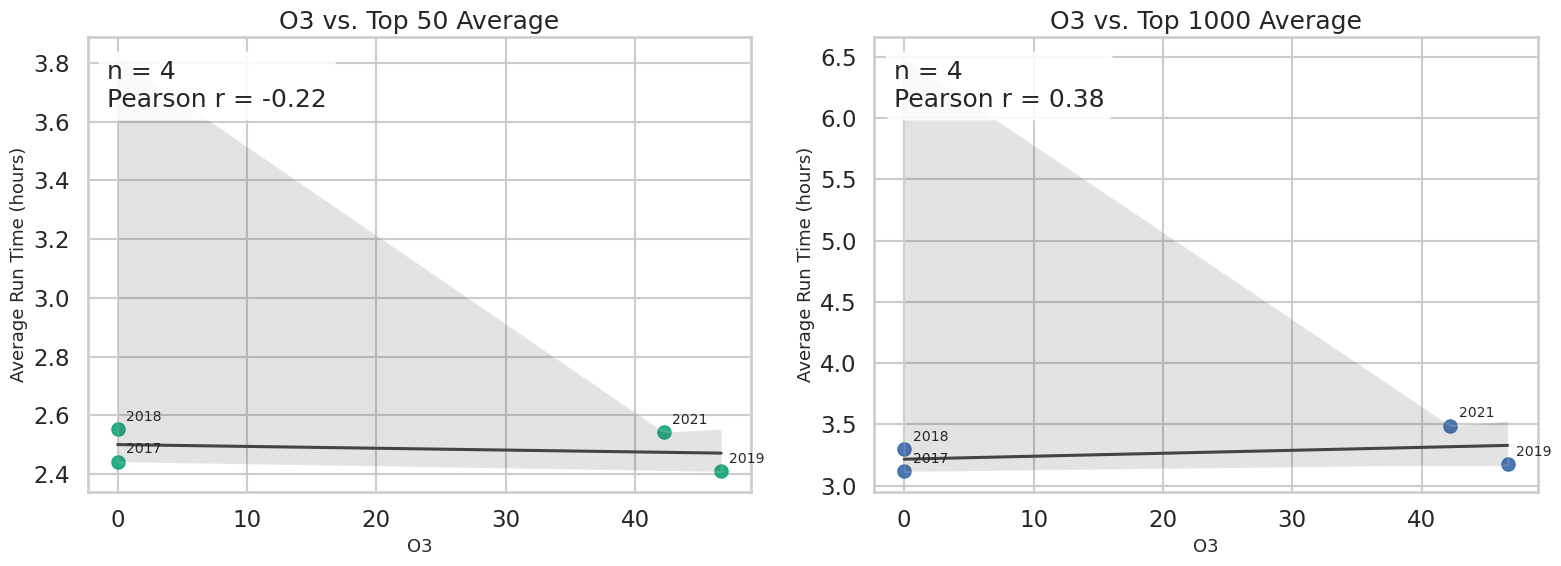

(   year         o3  avg_top_50_hours  avg_top_1000_hours
 0  2017   0.000000          2.442572            3.116924
 1  2018   0.000000          2.552578            3.300330
 2  2019  46.645400          2.409578            3.174321
 3  2021  42.207667          2.543383            3.489792,
       group  observations  pearson_correlation
 0    Top 50             4            -0.222936
 1  Top 1000             4             0.375502)

In [23]:
o3_performance_df = (
    air_performance_comparison_df[["year", "o3", "avg_top_50_hours", "avg_top_1000_hours"]]
    .dropna()
    .sort_values("year")
)

o3_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(o3_performance_df),
            "pearson_correlation": o3_performance_df["o3"].corr(
                o3_performance_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(o3_performance_df),
            "pearson_correlation": o3_performance_df["o3"].corr(
                o3_performance_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#11a579"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#3969ac"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=o3_performance_df,
        x="o3",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in o3_performance_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["o3"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = o3_correlation_table.loc[
        o3_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"O3 vs. {label} Average")
    ax.set_xlabel("O3")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(o3_performance_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

o3_performance_df, o3_correlation_table

## 8. Niederschlag: Top 50 vs. Top 1000

Neben der Temperatur kann auch Niederschlag den Lauf beeinflussen, zum Beispiel ueber nasse Strecke, mehr Energieaufwand und unguenstigere Gesamtbedingungen. Fuer eure Aussage ist interessant, ob sich dieser Effekt beim breiteren schnellen Feld staerker zeigt als bei der Elite.

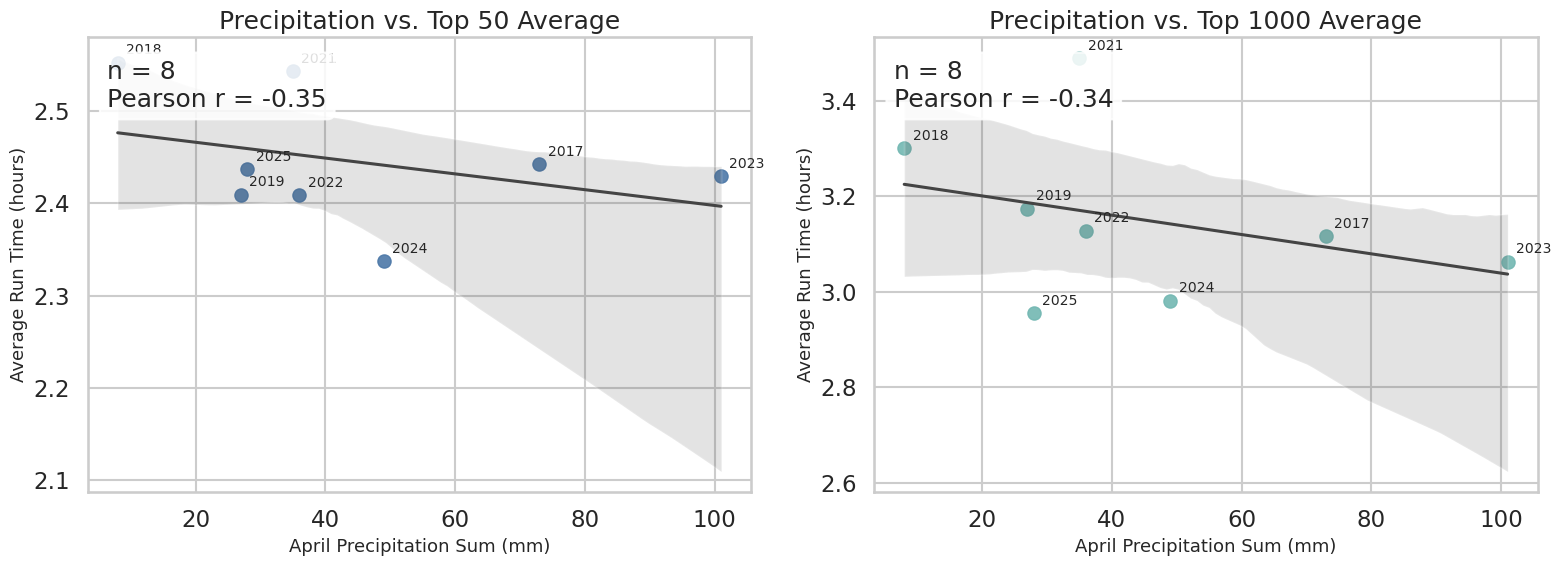

(   year  precipitation_mm  avg_top_50_hours  avg_top_1000_hours
 0  2017                73          2.442572            3.116924
 1  2018                 8          2.552578            3.300330
 2  2019                27          2.409578            3.174321
 3  2021                35          2.543383            3.489792
 4  2022                36          2.409267            3.127809
 5  2023               101          2.429778            3.063252
 6  2024                49          2.337167            2.981446
 7  2025                28          2.436933            2.954827,
       group  observations  pearson_correlation
 0    Top 50             8            -0.353663
 1  Top 1000             8            -0.341266)

In [24]:
precipitation_df = (
    weather_april_df[["REF_YEAR", "PRECP_SUM"]]
    .dropna()
    .rename(columns={"REF_YEAR": "year", "PRECP_SUM": "precipitation_mm"})
    .sort_values("year")
)

performance_vs_precipitation_df = (
    precipitation_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

precipitation_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(performance_vs_precipitation_df),
            "pearson_correlation": performance_vs_precipitation_df["precipitation_mm"].corr(
                performance_vs_precipitation_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(performance_vs_precipitation_df),
            "pearson_correlation": performance_vs_precipitation_df["precipitation_mm"].corr(
                performance_vs_precipitation_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#4c78a8"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#72b7b2"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_precipitation_df,
        x="precipitation_mm",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_precipitation_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["precipitation_mm"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = precipitation_correlation_table.loc[
        precipitation_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Precipitation vs. {label} Average")
    ax.set_xlabel("April Precipitation Sum (mm)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_precipitation_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_precipitation_df, precipitation_correlation_table

## 9. Naechste Schritte fuer die Praesentation

- Die Vergleiche fuer Temperatur, Niederschlag, PM2.5 und O3 darauf pruefen, ob Top 1000 konsistenter reagiert als Top 50.
- Fuer die Folien genau den Vergleich auswaehlen, bei dem der Unterschied zwischen Elite und breiterem Feld am klarsten erkennbar ist.
- Falls gewuenscht, im naechsten Schritt noch denselben Links-rechts-Vergleich fuer Top 500 oder eine kombinierte Uebersichtstabelle ergaenzen.